# Exploratory Data Analysis (EDA) with Data Visualization
### IBM Data Science Professional Certificate - Capstone Project
Analyzing correlations, trends, and feature patterns using Matplotlib and Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dataset_part_2.csv')
print("Loaded dataset_part_2.csv shape:", df.shape)

Loaded dataset_part_2.csv shape: (90, 18)


### Task 1: Flight Number vs Launch Site

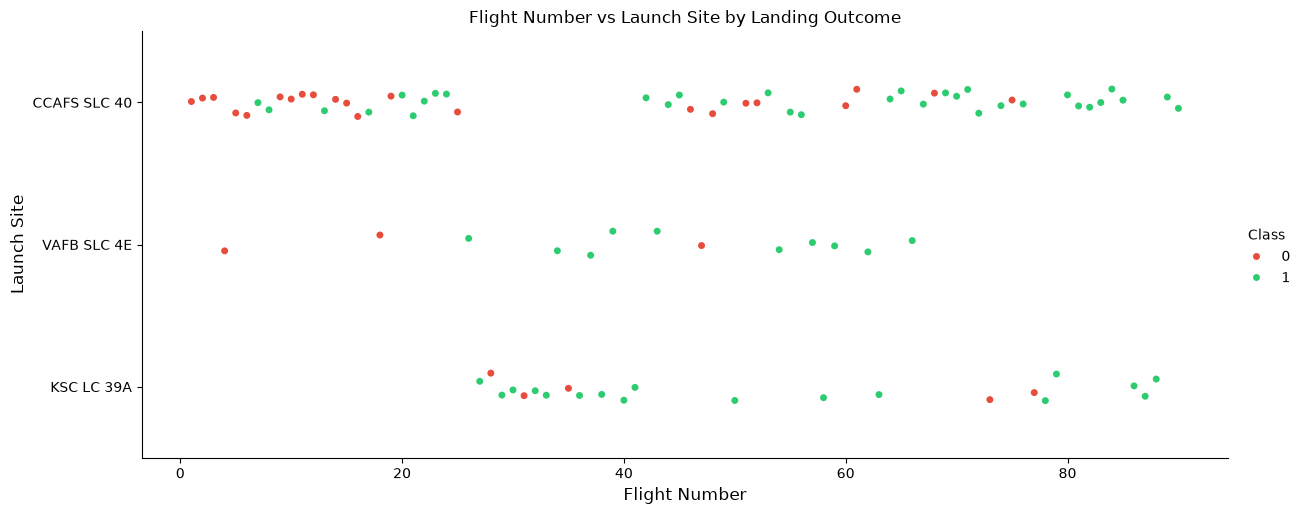

In [2]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=2.5, palette={0:"#e74c3c", 1:"#2ecc71"})
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.title("Flight Number vs Launch Site by Landing Outcome")
plt.show()

### Task 2: Payload Mass vs Launch Site

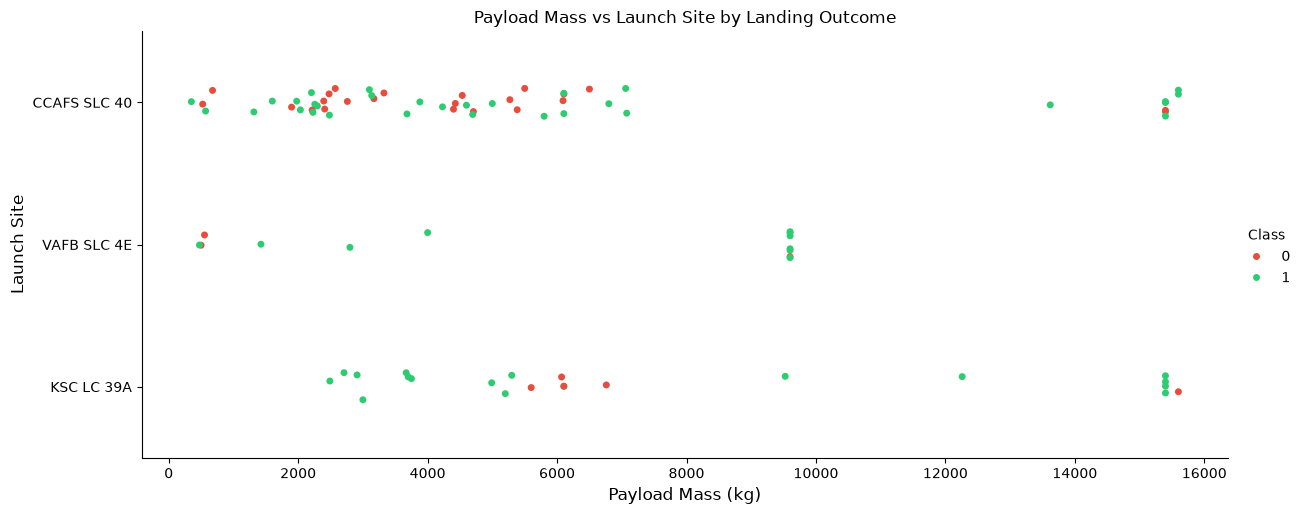

In [3]:
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=2.5, palette={0:"#e74c3c", 1:"#2ecc71"})
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.title("Payload Mass vs Launch Site by Landing Outcome")
plt.show()

### Task 3: Success Rate by Orbit Type

/var/folders/lj/_6z2fp793m787nkwcjtskyjm0000gn/T/ipykernel_12493/1814495723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Orbit", y="Class", data=orbit_success, palette="Blues_d")


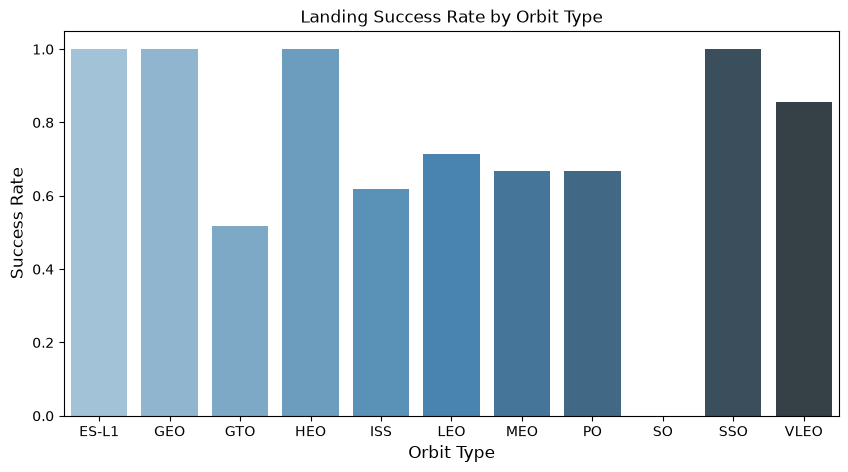

In [4]:
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x="Orbit", y="Class", data=orbit_success, palette="Blues_d")
plt.xlabel("Orbit Type", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.title("Landing Success Rate by Orbit Type")
plt.show()

### Task 4: Flight Number vs Orbit Type

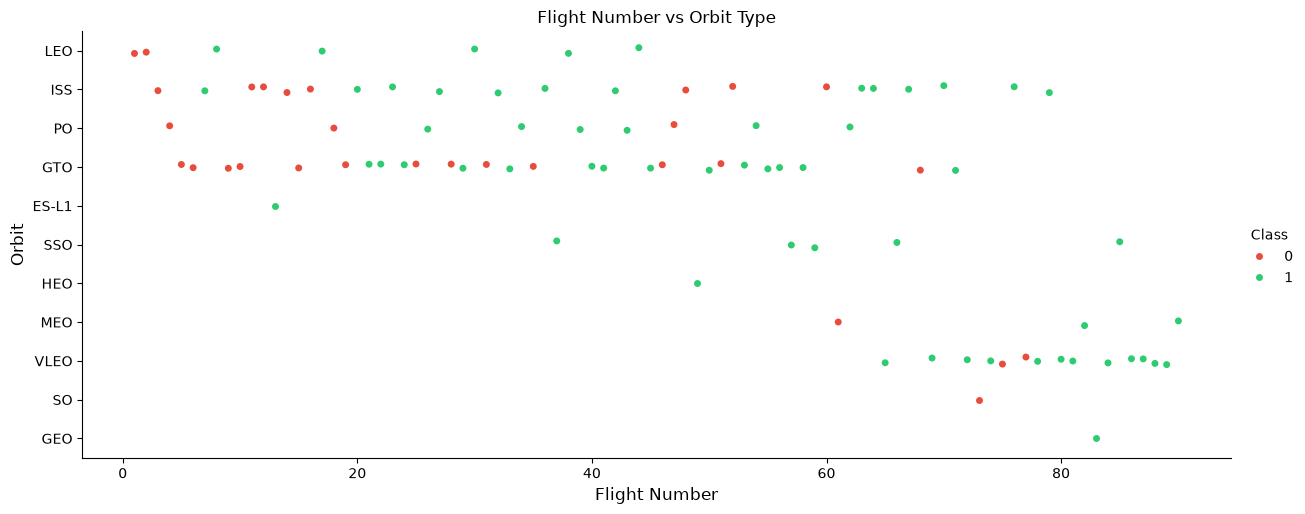

In [5]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=2.5, palette={0:"#e74c3c", 1:"#2ecc71"})
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Orbit", fontsize=12)
plt.title("Flight Number vs Orbit Type")
plt.show()

### Task 5: Payload Mass vs Orbit Type

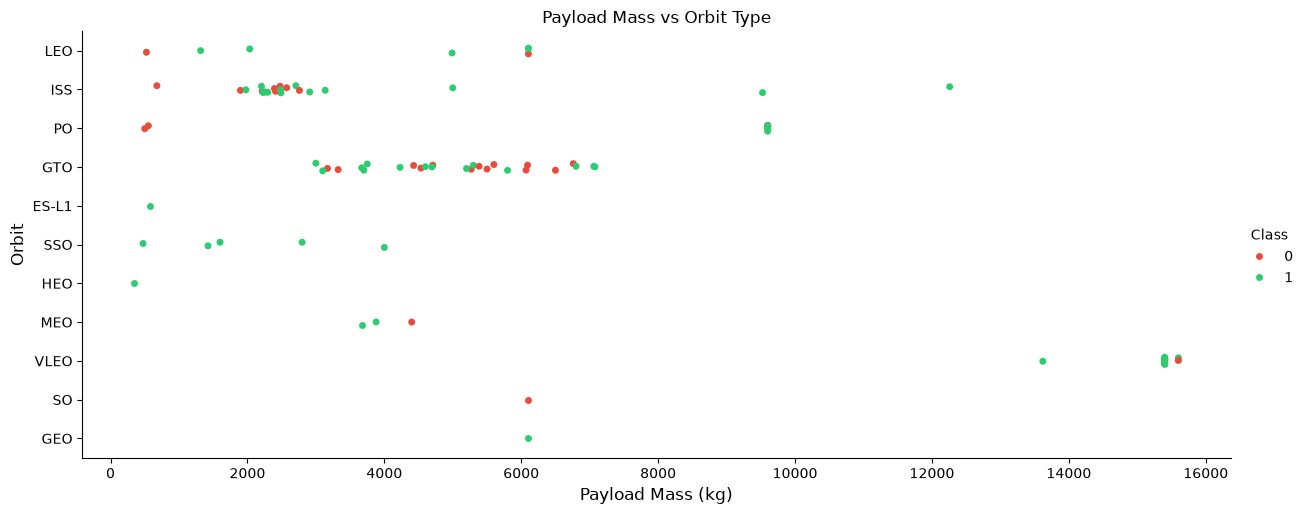

In [6]:
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=2.5, palette={0:"#e74c3c", 1:"#2ecc71"})
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Orbit", fontsize=12)
plt.title("Payload Mass vs Orbit Type")
plt.show()

### Task 6: Launch Success Yearly Trend

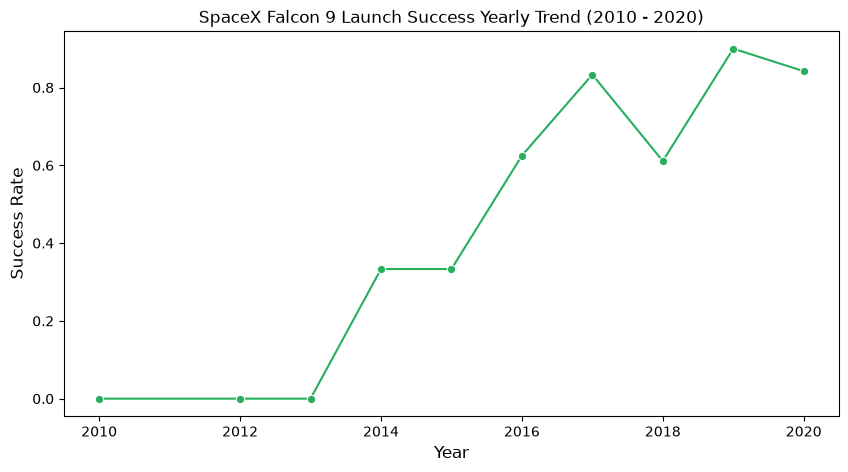

In [7]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['Class'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x="Year", y="Class", data=yearly_success, marker='o', color="#27ae60")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.title("SpaceX Falcon 9 Launch Success Yearly Trend (2010 - 2020)")
plt.show()

### Feature Engineering: One-Hot Encoding

In [8]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot = features_one_hot.astype('float64')
print("Engineered features shape:", features_one_hot.shape)
features_one_hot.to_csv('../data/dataset_part_3.csv', index=False)
print("Saved dataset_part_3.csv successfully.")

Engineered features shape: (90, 80)
Saved dataset_part_3.csv successfully.
